In [47]:
library(Seurat)
library(arrow)
library(dplyr)
library(ggplot2)
library(sf)
library(Seurat)
library(Matrix)
library(rhdf5)

ERROR: Error in library(rhdf5): there is no package called ‘rhdf5’


# Read all cells object and write to non-Seurat formats

In [31]:
allcells <- readRDS("out_rds/allcells_qc_harm_umap_clusters_annotation_tessera.rds")
allcells.meta <- allcells@meta.data

allcells.meta$celltype.med <- NA_character_
allcells.meta$celltype.fine <- NA_character_
allcells.meta$celltype.ultrafine <- NA_character_
names(allcells.meta)[names(allcells.meta) == "celltypes.coarse"] <- "celltype.coarse"

In [33]:
allcells.meta$cellid <- rownames(allcells.meta)
write_parquet(allcells.meta, "out_h5ad/allcells-meta.parquet")

In [44]:
# write out UMAP coords
write_parquet(data.frame(Embeddings(allcells, "humap")), "out_h5ad/allcells-humap.parquet")
write_parquet(data.frame(Embeddings(allcells, "harmony")), "out_h5ad/allcells-harmony.parquet")

In [ ]:
# write out NNG

In [46]:
# write out normalized counts matrix
X <- LayerData(allcells, assay = "RNA", layer = "data")
if (!inherits(X, "dgCMatrix")) {
  X <- as(X, "dgCMatrix")
}

outfile <- "out_h5ad/allcells-data.h5"

h5createFile(outfile)
h5write(X@x, outfile, "x")
h5write(X@i, outfile, "i")
h5write(X@p, outfile, "p")
h5write(as.integer(dim(X)), outfile, "shape")
h5write(rownames(X), outfile, "var_names")
h5write(colnames(X), outfile, "obs_names")

ERROR: Error in h5createFile(outfile): could not find function "h5createFile"


# Add fine types to cell metadata

In [18]:
allcells.meta <- as.data.frame(read_parquet("out_h5ad/allcells-meta.parquet"))
rownames(allcells.meta) <- allcells.meta$cellid

In [20]:
# 2) Transfer metadata columns from each finetyped object
coarsetypes <- c("B", "Lining", "NK", "Sublining", "T")
cols_to_transfer <- c("celltype.med", "celltype.fine", "celltype.ultrafine")

for (coarsetype in coarsetypes) {
  message("Processing ", coarsetype, "...")
  
  fine_obj <- readRDS(paste0("out_rds/intermediate/_", coarsetype, "_finetyped.rds"))
  fine.meta <- fine_obj@meta.data
  
  common_cells <- intersect(rownames(allcells.meta), rownames(fine.meta))
  if (length(common_cells) == 0) {
    message("  No overlapping cells found; skipping.")
    next
  }
  
  existing_cols <- intersect(cols_to_transfer, colnames(fine.meta))
  if (length(existing_cols) == 0) {
    message("  No transfer columns found; skipping.")
    next
  }
  
  allcells.meta[common_cells, existing_cols] <- fine.meta[common_cells, existing_cols, drop = FALSE]
  message("  Transferred columns: ", paste(existing_cols, collapse = ", "))
}

Processing B...

  Transferred columns: celltype.fine

Processing Lining...

  Transferred columns: celltype.fine

Processing NK...

  Transferred columns: celltype.fine

Processing Sublining...

  Transferred columns: celltype.fine

Processing T...

  Transferred columns: celltype.fine, celltype.ultrafine



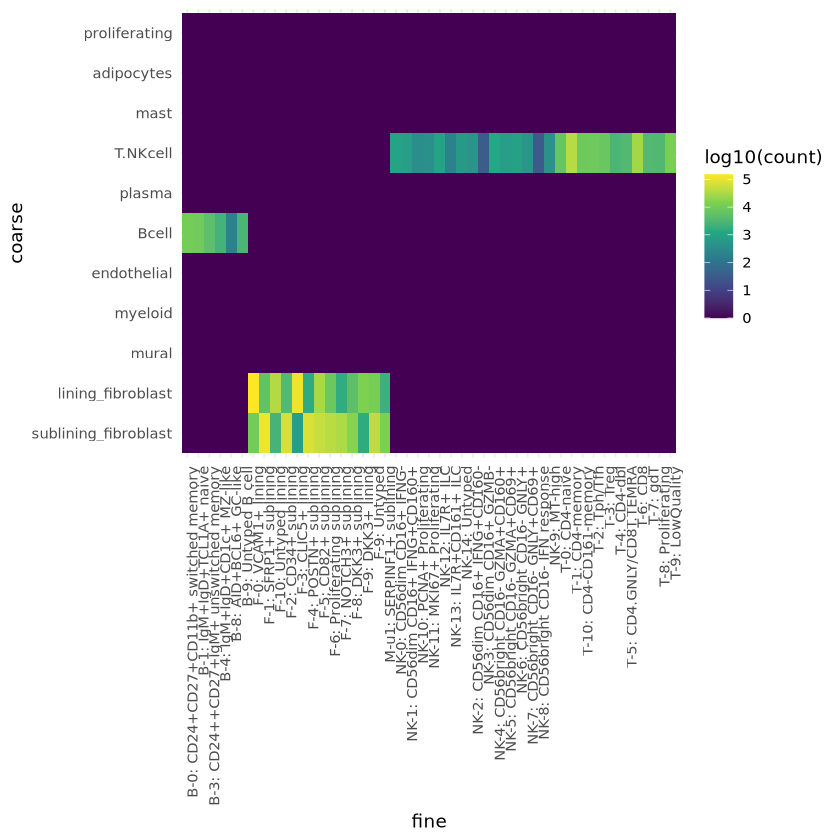

In [26]:
tab <- as.data.frame(table(
  coarse = allcells.meta$celltype.coarse,
  fine   = allcells.meta$celltype.fine
))

ggplot(tab, aes(x = fine, y = coarse, fill = log10(Freq + 1))) +
  geom_tile() +
  scale_fill_viridis_c(name = "log10(count)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

In [28]:
# 3) Save metadata table as parquet
write_parquet(
  allcells.meta,
  "out_h5ad/allcells-meta.parquet"
)

# Export tiles

In [2]:
tiles <- readRDS("out_rds/tiles.rds")

In [3]:
md <- tiles@meta.data
md$shape_wkb <- st_as_binary(st_sfc(md$shape))

In [5]:
md <- tiles@meta.data
md$tile_key <- rownames(md)
shape_sfc <- st_sfc(md$shape)

shape_df <- data.frame(
  tile_key = md$tile_key,
  shape_wkb = I(st_as_binary(shape_sfc))
)

meta_df <- md
meta_df$shape <- NULL

write_parquet(meta_df, "out_h5ad/tiles-meta.parquet")
write_parquet(shape_df, "out_h5ad/tiles-shape.parquet")

# Scratch

In [ ]:
X <- as(GetAssayData(seu_qc, layer = "data"), "dgCMatrix")
A <- as(seu_qc@graphs$humap_fgraph, "dgCMatrix")

obs <- seu_qc@meta.data
hPCs <- Embeddings(seu_qc, "harmony")
UMAP <- Embeddings(seu_qc, "humap")
cellnames = colnames(seu_qc)
genenames = rownames(seu_qc)

In [ ]:
#TODO: probably should use h5ad file instead of text-based mtx format
cat("writing X"); flush.console()
writeMM(as(X, "dgCMatrix"), "out/allcells_qc_harm_umap_clusters_annotation.data.mtx")
cat("writing A"); flush.console()
writeMM(as(A, "dgCMatrix"), "out/allcells_qc_harm_umap_clusters_annotation.graph.mtx")
cat("writing obs"); flush.console()
write_parquet(obs, "out/allcells_qc_harm_umap_clusters_annotation.meta.parquet")
cat("writing hPCs"); flush.console()
write_parquet(as.data.frame(hPCs),
              "out/allcells_qc_harm_umap_clusters_annotation.harmony.parquet")
cat("writing UMAP coords"); flush.console()
write_parquet(as.data.frame(UMAP),
              "out/allcells_qc_harm_umap_clusters_annotation.umap.parquet")
cat("writing row and column names"); flush.console()
writeLines(rownames(X), "out/allcells_qc_harm_umap_clusters_annotation.genes.txt")
writeLines(colnames(X), "out/allcells_qc_harm_umap_clusters_annotation.cells.txt")